<style>
:root{--navy:#102a43;--blue:#184e77;--teal:#2a9d8f;--gold:#e9b949;--red:#d95d4f;--ink:#172033;--muted:#526b7a;--pale:#edf5fb;--mint:#ddf4ef;--sand:#fff4d6}
.eda-hero{padding:38px 42px;border-radius:24px;color:#f8fbff;background:radial-gradient(circle at 92% 8%,rgba(255,255,255,.16) 0 8%,transparent 9%),linear-gradient(125deg,var(--navy),var(--blue) 56%,var(--teal));box-shadow:0 16px 38px #102a433d;font-family:Inter,'Segoe UI',Arial,sans-serif}
.eda-hero h1{margin:16px 0 9px;color:white;font-size:37px;line-height:1.15}.eda-hero h2{margin:0;color:white;font-size:20px;font-weight:450}.chips{display:flex;gap:8px;flex-wrap:wrap}.chips span{padding:6px 13px;border:1px solid #ffffff55;border-radius:999px;background:#ffffff20;font-size:11px;font-weight:800;letter-spacing:.05em}.hero-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(205px,1fr));gap:12px;margin-top:25px}.hero-card{padding:13px 15px;border:1px solid #ffffff3d;border-radius:11px;background:#ffffff12}.hero-card b{display:block;font-size:11px;text-transform:uppercase;letter-spacing:.07em;opacity:.8;margin-bottom:4px}
.section{margin:28px 0 14px;padding:16px 22px;border-radius:14px;background:linear-gradient(90deg,var(--navy),var(--blue));color:white;font-family:Inter,'Segoe UI',Arial,sans-serif}.section h2{margin:0;color:white;font-size:24px}.section p{margin:5px 0 0;opacity:.9}
.callout{margin:14px 0;padding:17px 21px;border:1px solid #c9d9e6;border-left:6px solid var(--teal);border-radius:12px;background:var(--pale);color:var(--ink);line-height:1.65}.callout.warn{border-left-color:var(--gold);background:var(--sand)}.callout.stop{border-left-color:var(--red);background:#fceae6}.metric-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:10px;margin:12px 0}.metric{padding:13px 14px;border-radius:10px;background:var(--pale);border:1px solid #d6e3ec;text-align:center}.metric strong{display:block;color:var(--teal);font-size:23px}.metric span{display:block;color:var(--muted);font-size:11px;font-weight:750;text-transform:uppercase;letter-spacing:.04em}.verdict{display:grid;grid-template-columns:repeat(auto-fit,minmax(225px,1fr));gap:11px}.verdict>div{padding:15px 17px;border-radius:11px;background:#f8fbfd;border:1px solid #cfdee8}.verdict b{color:var(--blue)}
table{font-size:13px!important}thead th{background:#184e77!important;color:white!important;text-align:left!important}tbody tr:nth-child(even){background:#f3f8fb}td,th{padding:7px 9px!important}.jp-RenderedHTMLCommon code{background:#102a4312;padding:2px 5px;border-radius:4px}
</style>
<div class="eda-hero">
  <div class="chips"><span>DEEP LEARNING</span><span>PROYECTO 1</span><span>EDA DIAGNÓSTICO</span><span>IEEE-CIS</span><span>GRUPO 1</span></div>
  <h1>Antes de cambiar el modelo: entender los datos</h1>
  <h2>Análisis causal, temporal y multivariado para explicar las limitaciones observadas en V6</h2>
  <div class="hero-grid">
    <div class="hero-card"><b>Institución</b>Universidad del Valle de Guatemala</div>
    <div class="hero-card"><b>Curso</b>Deep Learning y Sistemas Inteligentes</div>
    <div class="hero-card"><b>Docente</b>Kevin Recinos</div>
    <div class="hero-card"><b>Integrantes</b>Wilson Alejandro Calderón Argueta · 22018<br>Pablo Daniel Barillas Moreno · 22193</div>
    <div class="hero-card"><b>Fuente</b>IEEE-CIS Fraud Detection</div>
    <div class="hero-card"><b>Propósito</b>Diagnosticar señal, ruido, deriva, identidad y redundancia</div>
  </div>
</div>

<div class="section"><h2>0 · Pregunta, alcance y reglas</h2><p>El EDA decide qué experimentar después; no altera modelos ni métricas.</p></div>

Antes de aumentar épocas o complejidad se investigan cinco causas alternativas:

1. **Señal insuficiente o mal representada:** variables útiles descartadas o códigos tratados como magnitudes.
2. **Ruido e identificadores:** columnas casi únicas que permiten memorizar el período.
3. **Ausencia informativa:** en IEEE-CIS un faltante puede describir canal, producto o cobertura de identidad.
4. **Deriva temporal:** la distribución puede cambiar entre entrenamiento, validación y benchmark.
5. **Entidad secuencial imperfecta:** una clave proxy puede mezclar usuarios o fragmentar a una persona.

La correlación lineal y la varianza acumulada de PCA se usan como diagnósticos:

$$r_{X,Y}=\frac{\operatorname{cov}(X,Y)}{\sigma_X\sigma_Y},
\qquad EVR(k)=\frac{\sum_{j=1}^{k}\lambda_j}{\sum_{j=1}^{p}\lambda_j}.$$

Una correlación baja no implica ausencia de señal predictiva. PCA tampoco garantiza mejor AP: maximiza varianza, no separación de fraude.

<div class="callout warn"><b>Regla causal:</b> cualquier selección definitiva, imputación, PCA o codificación deberá ajustarse solamente con entrenamiento dentro de cada ventana temporal.</div>

In [1]:
from __future__ import annotations
import gc, os, re, warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

SEED, CHUNK_SIZE, SAMPLE_FRAC, PCA_SAMPLE = 22193, 60_000, 0.05, 20_000
COLORS={"navy":"#102A43","blue":"#184E77","teal":"#2A9D8F","gold":"#E9B949","red":"#D95D4F","muted":"#526B7A"}
plt.rcParams.update({"figure.figsize":(11.5,4.8),"figure.dpi":115,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.titleweight":"bold","axes.titlecolor":COLORS["navy"],
                     "axes.labelcolor":COLORS["muted"],"font.size":10,"grid.alpha":.18})
pd.set_option("display.max_columns",30); pd.set_option("display.max_rows",30)
pd.set_option("display.float_format",lambda x:f"{x:,.4f}")

def locate_root():
    explicit=os.environ.get("PROJECT1_ROOT")
    if explicit and (Path(explicit)/"datos/raw/train_transaction.csv").exists():
        return Path(explicit).resolve()
    start=Path.cwd().resolve()
    for candidate in [start,*start.parents]:
        if (candidate/"datos/raw/train_transaction.csv").exists(): return candidate
    raise FileNotFoundError("Defina PROJECT1_ROOT o ejecute desde la raíz del repositorio.")

ROOT=locate_root(); RAW=ROOT/"datos/raw"
TX_PATH=RAW/"train_transaction.csv"; ID_PATH=RAW/"train_identity.csv"
display(HTML(f'<div class="callout"><b>Entorno listo.</b> <code>{ROOT}</code><br>'
             f'Semilla: {SEED} · bloques: {CHUNK_SIZE:,} · muestra: {SAMPLE_FRAC:.0%}</div>'))

<div class="section"><h2>1 · Lectura eficiente e inventario</h2><p>Una pasada por el archivo conserva estadísticas globales y una muestra reproducible.</p></div>

Las filas, prevalencia, faltantes y duplicados se calculan sobre el conjunto completo. Asociación, correlación y PCA emplean una muestra temporal reproducible para controlar memoria.

In [2]:
tx_header=pd.read_csv(TX_PATH,nrows=0).columns.tolist()
id_header=pd.read_csv(ID_PATH,nrows=0).columns.tolist()
core_candidates=["TransactionID","isFraud","TransactionDT","TransactionAmt","ProductCD",
    "card1","card2","card3","card4","card5","card6","addr1","addr2","dist1","dist2",
    "P_emaildomain","R_emaildomain",*[f"C{i}" for i in range(1,15)],
    *[f"D{i}" for i in range(1,16)],*[f"M{i}" for i in range(1,10)]]
core_cols=[c for c in core_candidates if c in tx_header]
missing_tx=pd.Series(0,index=tx_header,dtype="int64")
sample_parts=[]; core_parts=[]; row_offset=0
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for chunk_no,chunk in enumerate(pd.read_csv(TX_PATH,chunksize=CHUNK_SIZE,low_memory=False)):
        n=len(chunk); chunk["_row"]=np.arange(row_offset,row_offset+n,dtype=np.int64)
        missing_tx=missing_tx.add(chunk[tx_header].isna().sum(),fill_value=0).astype("int64")
        sample_parts.append(chunk.sample(frac=SAMPLE_FRAC,random_state=SEED+chunk_no))
        core_parts.append(chunk[core_cols+["_row"]].copy()); row_offset+=n
tx_sample=pd.concat(sample_parts,ignore_index=True); core=pd.concat(core_parts,ignore_index=True)
del sample_parts,core_parts; gc.collect()
identity=pd.read_csv(ID_PATH,low_memory=False)
id_missing=pd.Series({c:(len(core)-len(identity))+int(identity[c].isna().sum())
                      for c in id_header if c!="TransactionID"},dtype="int64")
sample=tx_sample.merge(identity,on="TransactionID",how="left",validate="one_to_one")
n_rows=len(core); n_fraud=int(core.isFraud.sum()); prevalence=n_fraud/n_rows
split_train=int(n_rows*.70); split_val=int(n_rows*.85)
core["periodo"]=np.select([core._row<split_train,core._row<split_val],
                          ["Entrenamiento","Validación"],default="Benchmark")
sample["periodo"]=np.select([sample._row<split_train,sample._row<split_val],
                            ["Entrenamiento","Validación"],default="Benchmark")
inventory=pd.DataFrame({"Tabla":["train_transaction","train_identity","Unión teórica"],
    "Filas":[n_rows,len(identity),n_rows],"Columnas":[len(tx_header),len(id_header),len(tx_header)+len(id_header)-1],
    "Cobertura":[1,len(identity)/n_rows,1]})
display(inventory.style.format({"Filas":"{:,.0f}","Cobertura":"{:.2%}"}))
display(HTML('<div class="metric-grid">'+
    f'<div class="metric"><strong>{n_rows:,}</strong><span>Transacciones</span></div>'+
    f'<div class="metric"><strong>{n_fraud:,}</strong><span>Fraudes</span></div>'+
    f'<div class="metric"><strong>{prevalence:.2%}</strong><span>Prevalencia</span></div>'+
    f'<div class="metric"><strong>{len(tx_header)+len(id_header)-1}</strong><span>Variables unidas</span></div>'+
    f'<div class="metric"><strong>{len(identity)/n_rows:.2%}</strong><span>Cobertura identidad</span></div>'+
    f'<div class="metric"><strong>{len(sample):,}</strong><span>Muestra EDA</span></div></div>'))

,Tabla,Filas,Columnas,Cobertura
0,train_transaction,"590,540",394,100.00%
1,train_identity,"144,233",41,24.42%
2,Unión teórica,"590,540",434,100.00%


In [3]:
def family(col):
    if re.fullmatch(r"V\d+",col): return "V (Vesta)"
    if re.fullmatch(r"C\d+",col): return "C (conteos)"
    if re.fullmatch(r"D\d+",col): return "D (tiempo)"
    if re.fullmatch(r"M\d+",col): return "M (match)"
    if col.startswith("id_"): return "Identidad"
    if col.startswith("card"): return "Tarjeta"
    if col.startswith(("addr","dist")): return "Dirección/distancia"
    if "emaildomain" in col: return "Correo"
    if col in {"DeviceType","DeviceInfo"}: return "Dispositivo"
    if col in {"TransactionID","TransactionDT"}: return "Control/índice"
    if col=="isFraud": return "Objetivo"
    return "Transacción base"

missing_all=pd.concat([(missing_tx/n_rows).rename("missing_rate"),
                       (id_missing/n_rows).rename("missing_rate")])
missing_all=missing_all[~missing_all.index.duplicated()]
missing_df=missing_all.rename_axis("variable").reset_index()
missing_df["familia"]=missing_df.variable.map(family)
family_summary=(missing_df.groupby("familia")
    .agg(variables=("variable","count"),faltante_medio=("missing_rate","mean"),
         faltante_mediano=("missing_rate","median"),faltante_maximo=("missing_rate","max"))
    .sort_values("faltante_medio",ascending=False))
display(family_summary.style.format({"faltante_medio":"{:.1%}","faltante_mediano":"{:.1%}",
                                     "faltante_maximo":"{:.1%}"}))
invariant=[c for c in sample.columns if sample[c].nunique(dropna=True)<=1]
almost_empty=missing_df.query("missing_rate>=.95")
quality=pd.DataFrame({
    "Comprobación":["TransactionID duplicado en transacciones","TransactionID duplicado en identidad",
                   "Variables constantes en muestra","Variables con ≥95% faltante"],
    "Resultado":[core.TransactionID.duplicated().sum(),identity.TransactionID.duplicated().sum(),
                 len(invariant),len(almost_empty)]})
display(quality)
display(HTML(f'<div class="callout"><b>Lectura inicial.</b> Hay <b>{len(almost_empty)}</b> '
             f'variables con al menos 95% de ausencia y <b>{len(invariant)}</b> constantes. '
             'La ausencia informativa se separará de las columnas sin variación.</div>'))

,variables,faltante_medio,faltante_mediano,faltante_maximo
familia,,,,
Identidad,38,84.8%,82.4%,99.2%
Dispositivo,2,78.0%,78.0%,79.9%
D (tiempo),15,58.2%,52.5%,93.4%
M (match),9,49.9%,47.7%,59.3%
Correo,2,46.4%,46.4%,76.8%
Dirección/distancia,4,43.9%,35.4%,93.6%
V (Vesta),339,43.0%,47.3%,86.1%
Tarjeta,6,0.5%,0.3%,1.5%
C (conteos),14,0.0%,0.0%,0.0%


,Comprobación,Resultado
0,TransactionID duplicado en transacciones,0
1,TransactionID duplicado en identidad,0
2,Variables constantes en muestra,2
3,Variables con ≥95% faltante,9


<div class="section"><h2>2 · Objetivo, tiempo y desbalance</h2><p>La prevalencia global puede ocultar cambios de dificultad.</p></div>

Predecir siempre “no fraude” produciría aproximadamente 96.5% de accuracy sin detectar un caso. La referencia natural de AP para un ranking aleatorio es:

$$AP_{azar}\approx P(Y=1).$$

,transacciones,fraudes,prevalencia,monto_mediano
periodo,,,,
Entrenamiento,"413,378","14,538",3.517%,USD 68.95
Validación,"88,581","3,042",3.434%,USD 67.95
Benchmark,"88,581","3,083",3.480%,USD 68.50


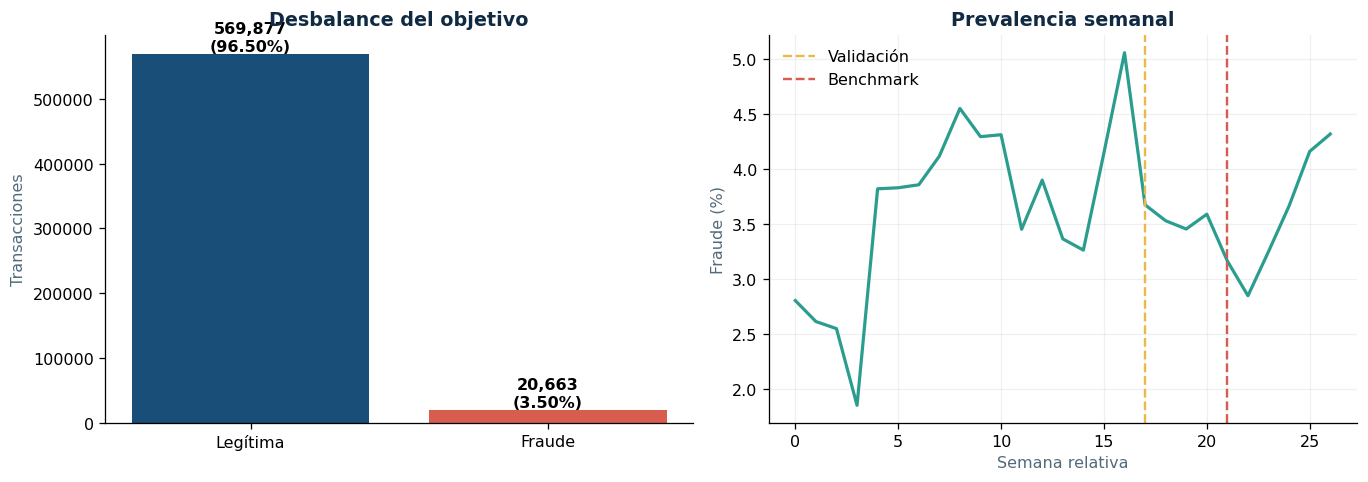

In [4]:
period_summary=(core.groupby("periodo",observed=True)
    .agg(transacciones=("isFraud","size"),fraudes=("isFraud","sum"),
         prevalencia=("isFraud","mean"),monto_mediano=("TransactionAmt","median"))
    .reindex(["Entrenamiento","Validación","Benchmark"]))
display(period_summary.style.format({"transacciones":"{:,.0f}","fraudes":"{:,.0f}",
    "prevalencia":"{:.3%}","monto_mediano":"USD {:,.2f}"}))
core["dia"]=core.TransactionDT/86_400; core["semana"]=(core.dia//7).astype(int)
weekly=core.groupby("semana").agg(n=("isFraud","size"),tasa_fraude=("isFraud","mean"))
fig,axes=plt.subplots(1,2,figsize=(12,4.3))
counts=core.isFraud.value_counts().sort_index()
axes[0].bar(["Legítima","Fraude"],counts.values,color=[COLORS["blue"],COLORS["red"]])
axes[0].set_title("Desbalance del objetivo"); axes[0].set_ylabel("Transacciones")
for i,v in enumerate(counts.values): axes[0].text(i,v,f"{v:,}\n({v/n_rows:.2%})",ha="center",va="bottom",fontweight="bold")
axes[1].plot(weekly.index,weekly.tasa_fraude*100,color=COLORS["teal"],lw=2)
axes[1].axvline(core.loc[split_train,"semana"],color=COLORS["gold"],ls="--",label="Validación")
axes[1].axvline(core.loc[split_val,"semana"],color=COLORS["red"],ls="--",label="Benchmark")
axes[1].set(title="Prevalencia semanal",xlabel="Semana relativa",ylabel="Fraude (%)")
axes[1].grid(True); axes[1].legend(frameon=False); plt.tight_layout(); plt.show()
rate_range=weekly.tasa_fraude.max()-weekly.tasa_fraude.min()
display(HTML(f'<div class="callout warn"><b>Diagnóstico temporal.</b> La tasa semanal cambia '
             f'{rate_range:.2%} puntos entre extremos. La validación debe avanzar en el tiempo '
             'y mantener la prevalencia natural.</div>'))

<div class="section"><h2>3 · Valores faltantes: problema y señal</h2><p>Se distingue entre casi vacío, ausencia asociada al objetivo y cambio temporal.</p></div>

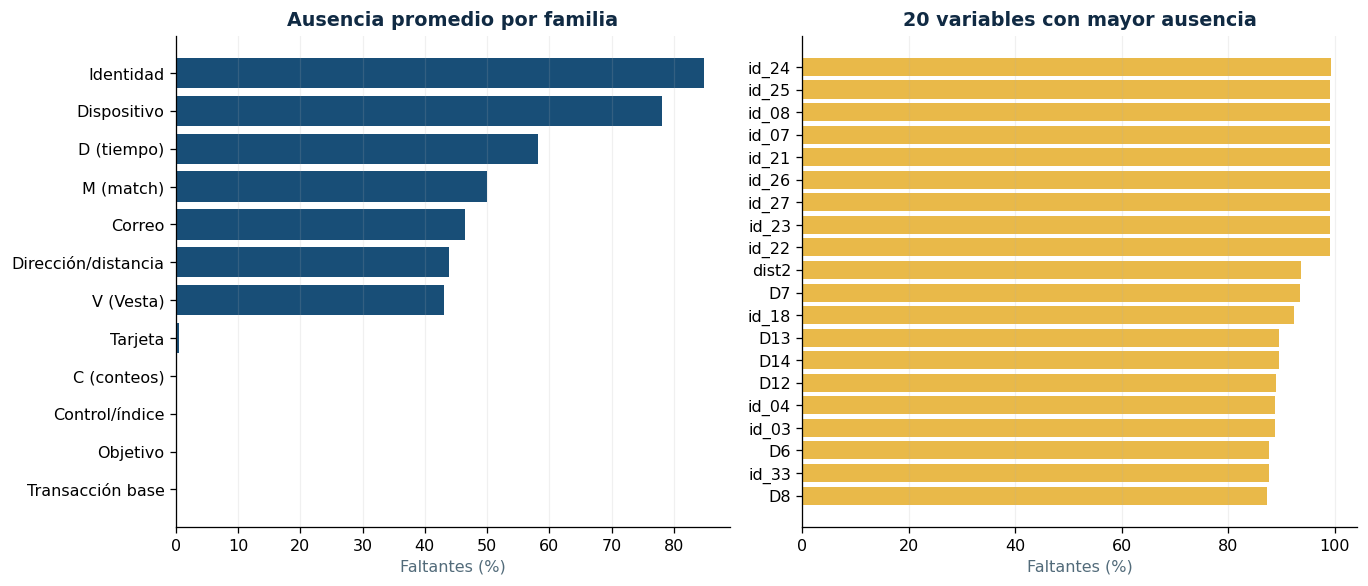

,variable,familia,missing_rate,fraud_si_falta,fraud_si_presente,delta_abs
12,D7,D (tiempo),93.6%,2.64%,15.51%,12.87%
19,D14,D (tiempo),89.6%,2.49%,11.92%,9.43%
17,D12,D (tiempo),89.2%,2.45%,11.85%,9.39%
2,addr2,Dirección/distancia,10.9%,11.70%,2.46%,9.25%
1,addr1,Dirección/distancia,10.9%,11.70%,2.46%,9.25%
285,id_03,Identidad,89.0%,2.47%,11.47%,8.99%
286,id_04,Identidad,89.0%,2.47%,11.47%,8.99%
18,D13,D (tiempo),89.6%,2.58%,11.15%,8.57%
290,id_10,Identidad,87.5%,2.40%,10.97%,8.57%
289,id_09,Identidad,87.5%,2.40%,10.97%,8.57%


In [5]:
fig,axes=plt.subplots(1,2,figsize=(12,5.2))
fam_plot=family_summary.sort_values("faltante_medio")
axes[0].barh(fam_plot.index,fam_plot.faltante_medio*100,color=COLORS["blue"])
axes[0].set(title="Ausencia promedio por familia",xlabel="Faltantes (%)"); axes[0].grid(axis="x")
top_missing=missing_df.nlargest(20,"missing_rate").sort_values("missing_rate")
axes[1].barh(top_missing.variable,top_missing.missing_rate*100,color=COLORS["gold"])
axes[1].set(title="20 variables con mayor ausencia",xlabel="Faltantes (%)"); axes[1].grid(axis="x")
plt.tight_layout(); plt.show()

y_sample=sample.isFraud.astype(int); rows=[]
for col in [c for c in sample.columns if c not in {"isFraud","_row","periodo"}]:
    miss=sample[col].isna()
    if not .01<miss.mean()<.99: continue
    fm=y_sample[miss].mean(); fp=y_sample[~miss].mean()
    rows.append({"variable":col,"familia":family(col),"missing_rate":miss.mean(),
                 "fraud_si_falta":fm,"fraud_si_presente":fp,"delta_abs":abs(fm-fp)})
missing_signal=pd.DataFrame(rows).sort_values("delta_abs",ascending=False)
display(missing_signal.head(20).style.format({"missing_rate":"{:.1%}","fraud_si_falta":"{:.2%}",
    "fraud_si_presente":"{:.2%}","delta_abs":"{:.2%}"}))
display(HTML('<div class="callout"><b>Implicación.</b> Para variables estables, un indicador '
             'de ausencia puede conservar señal que una imputación silenciosa eliminaría. '
             'Las casi vacías y constantes sí son candidatas a descarte.</div>'))

<div class="section"><h2>4 · Segmentos categóricos</h2><p>Los códigos se evalúan por soporte, tasa de fraude y lift; no como cantidades.</p></div>

$$lift(g)=\frac{P(Y=1\mid g)}{P(Y=1)}.$$

Se exige soporte mínimo para evitar conclusiones dominadas por categorías raras.

,variable,categoria,soporte,tasa_fraude,lift
586,V244,3.0,79,78.48%,22.63×
580,V242,3.0,69,75.36%,21.73×
589,V245,3.0,60,75.00%,21.63×
489,V194,2.0,68,72.06%,20.78×
492,V195,2.0,77,70.13%,20.22×
592,V246,3.0,77,68.83%,19.85×
486,V193,2.0,79,68.35%,19.71×
583,V243,3.0,94,65.96%,19.02×
480,V191,2.0,73,65.75%,18.96×
300,V87,4.0,59,64.41%,18.57×


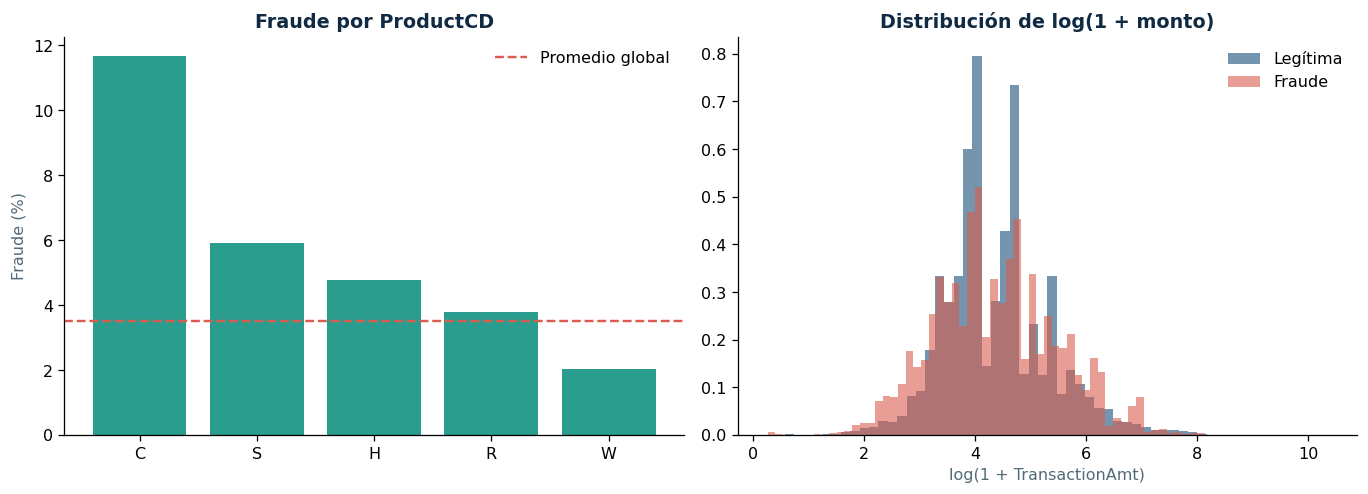

In [6]:
cat_candidates=[c for c in sample.columns if c not in {"isFraud","TransactionID","TransactionDT","_row","periodo"}
    and (sample[c].dtype=="object" or sample[c].nunique(dropna=True)<=50)]
cat_rows=[]; min_support=max(50,int(len(sample)*.002))
for col in cat_candidates:
    tmp=pd.DataFrame({"x":sample[col].astype("string").fillna("<NA>"),"y":y_sample})
    stats=tmp.groupby("x").y.agg(["size","mean"]); stats=stats[stats["size"]>=min_support]
    for level,row in stats.nlargest(3,"mean").iterrows():
        cat_rows.append({"variable":col,"categoria":str(level)[:42],"soporte":int(row["size"]),
                         "tasa_fraude":row["mean"],"lift":row["mean"]/y_sample.mean()})
cat_lift=pd.DataFrame(cat_rows).sort_values(["lift","soporte"],ascending=[False,False])
display(cat_lift.head(25).style.format({"soporte":"{:,.0f}","tasa_fraude":"{:.2%}","lift":"{:.2f}×"}))
product=core.groupby("ProductCD").isFraud.agg(["size","mean"]).sort_values("mean",ascending=False)
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
axes[0].bar(product.index.astype(str),product["mean"]*100,color=COLORS["teal"])
axes[0].axhline(prevalence*100,color=COLORS["red"],ls="--",label="Promedio global")
axes[0].set(title="Fraude por ProductCD",ylabel="Fraude (%)"); axes[0].legend(frameon=False)
for target,color,label in [(0,COLORS["blue"],"Legítima"),(1,COLORS["red"],"Fraude")]:
    axes[1].hist(np.log1p(core.loc[core.isFraud==target,"TransactionAmt"]),bins=60,density=True,
                 alpha=.6,color=color,label=label)
axes[1].set(title="Distribución de log(1 + monto)",xlabel="log(1 + TransactionAmt)")
axes[1].legend(frameon=False); plt.tight_layout(); plt.show()

<div class="section"><h2>5 · Asociación con fraude</h2><p>Correlación, información mutua y AP univariado evitan depender de una sola medida.</p></div>

- **Pearson** detecta relaciones aproximadamente lineales.
- **Información mutua** detecta dependencia más general.
- **AP univariado** indica si una variable sola ordena positivos; se prueban ambas direcciones.

Las cifras son exploratorias y se calculan sobre la muestra. La selección final debe repetirse dentro de entrenamiento.

,pearson,mutual_info,ap_univariado,direccion,abs_pearson,missing_rate,familia,nunique_muestra
card1,-0.0167,0.0533,0.0375,descendente,0.0167,0.0%,Tarjeta,"4,460"
card2,+0.0035,0.0229,0.0357,ascendente,0.0035,1.5%,Tarjeta,494
V258,+0.2803,0.0213,0.1858,ascendente,0.2803,77.9%,V (Vesta),28
V257,+0.3726,0.0204,0.1840,ascendente,0.3726,77.9%,V (Vesta),22
V246,+0.3572,0.0202,0.1779,ascendente,0.3572,77.9%,V (Vesta),19
V201,+0.3006,0.0193,0.1681,ascendente,0.3006,76.3%,V (Vesta),24
V187,+0.0257,0.0190,0.1142,ascendente,0.0257,76.4%,V (Vesta),61
V244,+0.3699,0.0184,0.1605,ascendente,0.3699,77.9%,V (Vesta),16
V200,+0.2971,0.0184,0.1617,ascendente,0.2971,76.3%,V (Vesta),21
V243,+0.2013,0.0183,0.1567,ascendente,0.2013,77.9%,V (Vesta),19


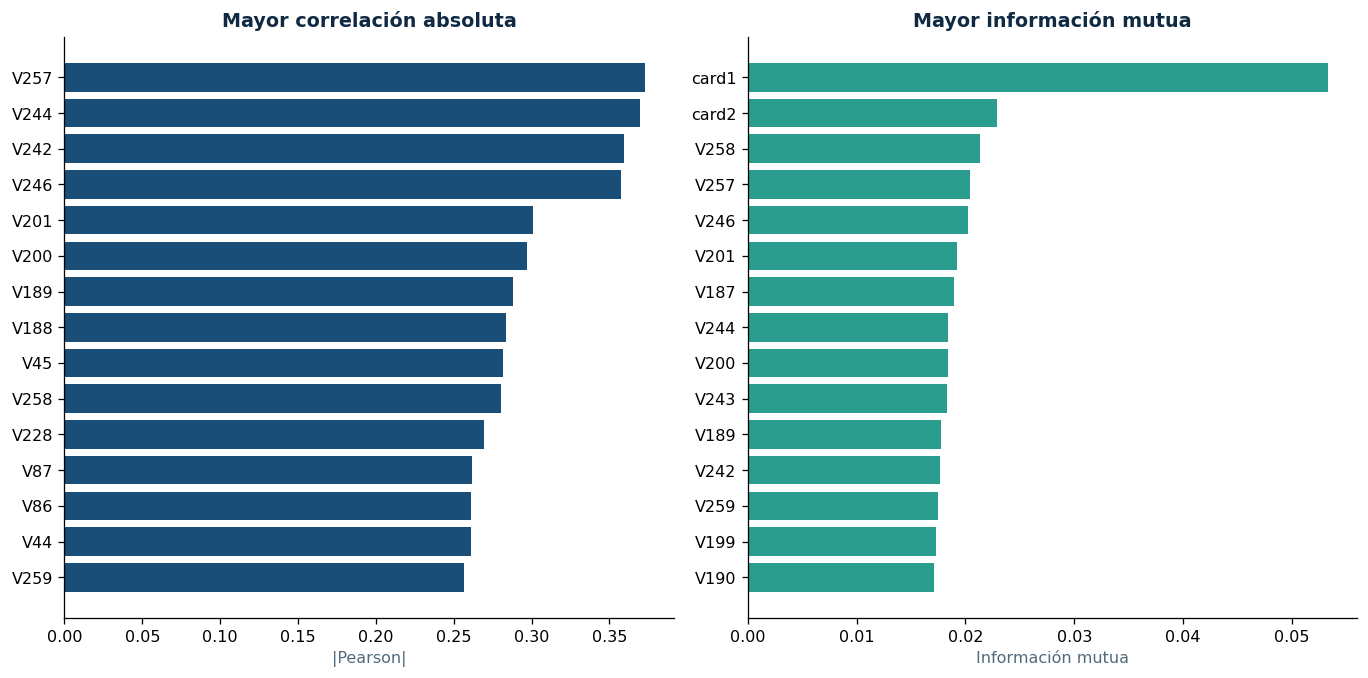

In [7]:
excluded={"isFraud","TransactionID","TransactionDT","_row","periodo"}
numeric_candidates=[c for c in sample.select_dtypes(include=np.number).columns
    if c not in excluded and sample[c].nunique(dropna=True)>1 and sample[c].isna().mean()<.95]
numeric_frame=sample[numeric_candidates].replace([np.inf,-np.inf],np.nan)
pearson=numeric_frame.corrwith(y_sample).rename("pearson")

mi_sample=sample.sample(n=min(15_000,len(sample)),random_state=SEED)
discrete_mask=np.array([mi_sample[c].nunique(dropna=True)<=50 or c.startswith(("card","addr"))
                        for c in numeric_candidates])
mi_arrays=[]
for col,is_discrete in zip(numeric_candidates,discrete_mask):
    values=mi_sample[col].replace([np.inf,-np.inf],np.nan)
    if is_discrete:
        encoded=pd.factorize(values.astype("string").fillna("<NA>"),sort=True)[0]
        mi_arrays.append(encoded.astype("float32"))
    else:
        numeric=pd.to_numeric(values,errors="coerce")
        mi_arrays.append(numeric.fillna(numeric.median()).to_numpy(dtype="float32"))
X_mi=np.column_stack(mi_arrays)
mi=pd.Series(mutual_info_classif(X_mi,mi_sample.isFraud.astype(int).to_numpy(),
    discrete_features=discrete_mask,random_state=SEED,n_neighbors=3),
    index=numeric_candidates,name="mutual_info")
del X_mi,mi_arrays; gc.collect()

base_rank=pd.concat([pearson.abs().rename("abs_corr"),mi],axis=1)
top_union=base_rank.nlargest(35,"abs_corr").index.union(base_rank.nlargest(35,"mutual_info").index)
ap_rows=[]
for col in top_union:
    values=sample[col].replace([np.inf,-np.inf],np.nan); filled=values.fillna(values.median())
    ap_pos=average_precision_score(y_sample,filled); ap_neg=average_precision_score(y_sample,-filled)
    ap_rows.append((col,max(ap_pos,ap_neg),"ascendente" if ap_pos>=ap_neg else "descendente"))
ap_uni=pd.DataFrame(ap_rows,columns=["variable","ap_univariado","direccion"]).set_index("variable")
association=(pd.concat([pearson,mi,ap_uni],axis=1)
    .assign(abs_pearson=lambda d:d.pearson.abs()).join(missing_all.rename("missing_rate"),how="left"))
association["familia"]=association.index.map(family)
association["nunique_muestra"]=[sample[c].nunique(dropna=True) for c in association.index]
association=association.sort_values(["mutual_info","abs_pearson"],ascending=False)
display(association.head(30).style.format({"pearson":"{:+.4f}","mutual_info":"{:.4f}",
    "ap_univariado":"{:.4f}","abs_pearson":"{:.4f}","missing_rate":"{:.1%}",
    "nunique_muestra":"{:,.0f}"}))

top_corr=association.nlargest(15,"abs_pearson").sort_values("abs_pearson")
top_mi=association.nlargest(15,"mutual_info").sort_values("mutual_info")
fig,axes=plt.subplots(1,2,figsize=(12,6))
axes[0].barh(top_corr.index,top_corr.abs_pearson,color=COLORS["blue"])
axes[0].set(title="Mayor correlación absoluta",xlabel="|Pearson|")
axes[1].barh(top_mi.index,top_mi.mutual_info,color=COLORS["teal"])
axes[1].set(title="Mayor información mutua",xlabel="Información mutua")
plt.tight_layout(); plt.show()
overlap=set(top_corr.index)&set(top_mi.index)
display(HTML(f'<div class="callout"><b>Lectura conjunta.</b> Solo <b>{len(overlap)}</b> variables '
             'coinciden en ambos top 15. Filtrar únicamente por correlación descartaría señal no lineal.</div>'))

<div class="section"><h2>6 · Identificadores y cardinalidad</h2><p>Una columna casi única puede memorizar el período sin generalizar.</p></div>

In [8]:
card_rows=[]
for col in sample.columns:
    if col in {"isFraud","_row","periodo"}: continue
    nunique=sample[col].nunique(dropna=True); present=sample[col].notna().sum()
    card_rows.append({"variable":col,"familia":family(col),"nunique":nunique,"presentes":present,
        "ratio_unicidad":nunique/max(present,1),"missing_rate":1-present/len(sample)})
cardinality=pd.DataFrame(card_rows).sort_values("ratio_unicidad",ascending=False)
suspicious=cardinality.query("ratio_unicidad>=.80 or variable in ['TransactionID','TransactionDT']").head(30)
display(suspicious.style.format({"nunique":"{:,.0f}","presentes":"{:,.0f}",
    "ratio_unicidad":"{:.1%}","missing_rate":"{:.1%}"}))
decisions=pd.DataFrame([
    ("TransactionID","Excluir del vector","Llave de unión y auditoría; casi único."),
    ("TransactionDT","No usar como magnitud bruta","Orden causal y variables de calendario; identifica el período."),
    ("card1–card6","Tratar como categorías/entidad","Los códigos no representan una escala."),
    ("addr1–addr2","Tratar como categorías","La distancia entre códigos no tiene interpretación."),
    ("DeviceInfo/id_31","Controlar rareza","Alta cardinalidad y cobertura parcial.")
],columns=["Variable o grupo","Decisión provisional","Justificación"])
display(decisions)

,variable,familia,nunique,presentes,ratio_unicidad,missing_rate
0,TransactionID,Control/índice,"29,527","29,527",100.0%,0.0%
1,TransactionDT,Control/índice,"29,483","29,527",99.9%,0.0%
394,id_02,Identidad,"6,903","6,971",99.0%,76.4%


,Variable o grupo,Decisión provisional,Justificación
0,TransactionID,Excluir del vector,Llave de unión y auditoría; casi único.
1,TransactionDT,No usar como magnitud bruta,Orden causal y variables de calendario; identi...
2,card1–card6,Tratar como categorías/entidad,Los códigos no representan una escala.
3,addr1–addr2,Tratar como categorías,La distancia entre códigos no tiene interpreta...
4,DeviceInfo/id_31,Controlar rareza,Alta cardinalidad y cobertura parcial.


<div class="section"><h2>7 · Redundancia entre variables</h2><p>La colinealidad importa más para modelos lineales y redes que para árboles.</p></div>

,variable_1,variable_2,spearman,abs_spearman
10629,V17,V18,+1.0000,1.0000
11715,V21,V22,+0.9999,0.9999
45427,V286,V311,+0.9999,0.9999
25235,V92,V93,+0.9998,0.9998
10080,V15,V16,+0.9997,0.9997
13599,V31,V32,+0.9997,0.9997
27464,V104,V135,+0.9997,0.9997
45842,V297,V319,+0.9996,0.9996
34292,V173,V206,+0.9996,0.9996
27851,V106,V137,+0.9996,0.9996


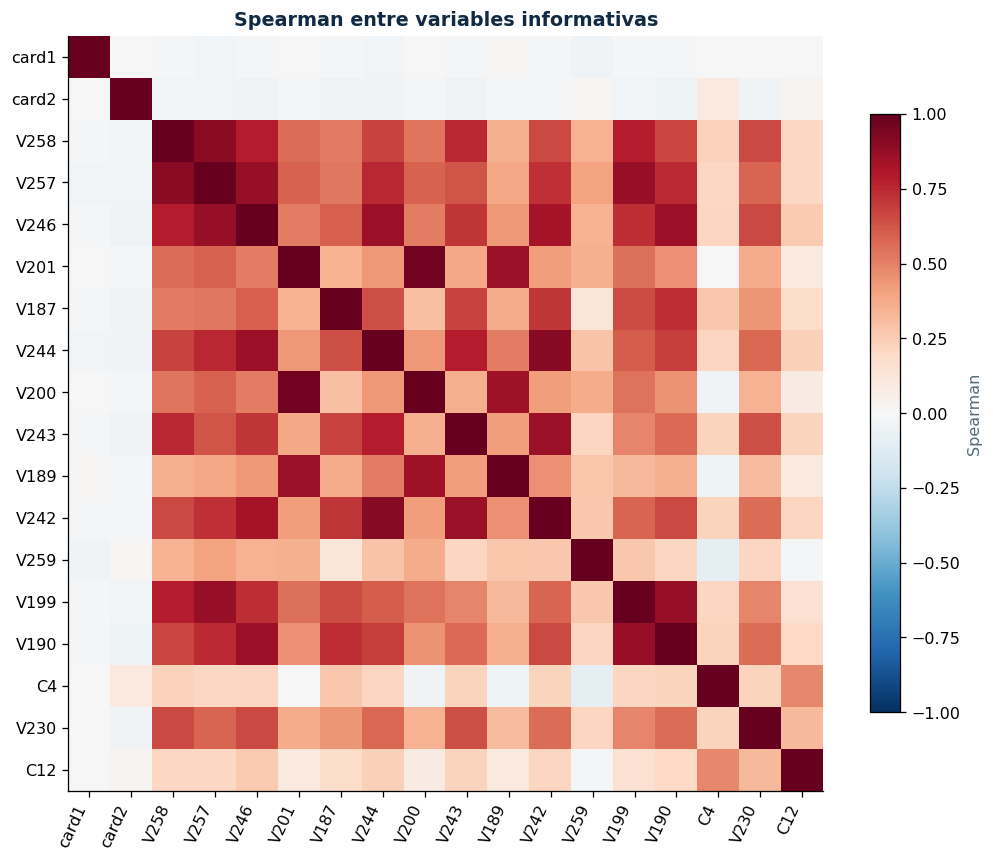

In [9]:
redundancy_cols=[c for c in numeric_candidates if sample[c].isna().mean()<.80
                 and sample[c].nunique(dropna=True)>2]
corr_features=sample[redundancy_cols].corr(method="spearman")
upper=corr_features.where(np.triu(np.ones(corr_features.shape),k=1).astype(bool))
pairs=(upper.stack().rename("spearman").reset_index()
       .rename(columns={"level_0":"variable_1","level_1":"variable_2"}))
pairs["abs_spearman"]=pairs.spearman.abs()
strong_pairs=pairs.query("abs_spearman>=.95").sort_values("abs_spearman",ascending=False)
display(strong_pairs.head(30).style.format({"spearman":"{:+.4f}","abs_spearman":"{:.4f}"}))

available_assoc=association.loc[association.index.intersection(redundancy_cols)]
heat_cols=available_assoc.nlargest(min(18,len(available_assoc)),"mutual_info").index
heat=sample[list(heat_cols)].corr(method="spearman")
fig,ax=plt.subplots(figsize=(9,7.5)); image=ax.imshow(heat,cmap="RdBu_r",vmin=-1,vmax=1)
ax.set_xticks(range(len(heat_cols)),heat_cols,rotation=65,ha="right")
ax.set_yticks(range(len(heat_cols)),heat_cols); ax.set_title("Spearman entre variables informativas")
fig.colorbar(image,ax=ax,shrink=.78,label="Spearman"); plt.tight_layout(); plt.show()
display(HTML('<div class="metric-grid">'+
    f'<div class="metric"><strong>{len(redundancy_cols)}</strong><span>Numéricas evaluadas</span></div>'+
    f'<div class="metric"><strong>{len(strong_pairs)}</strong><span>Pares |ρ| ≥ .95</span></div>'+
    f'<div class="metric"><strong>{len(set(strong_pairs.variable_1)|set(strong_pairs.variable_2))}</strong><span>Variables implicadas</span></div></div>'))

<div class="section"><h2>8 · PCA sobre la familia V</h2><p>Se prueba compresión geométrica, no mejora predictiva.</p></div>

PCA puede ser útil para una regresión o rama neuronal, pero no es automáticamente conveniente para LightGBM: mezcla variables y reduce interpretabilidad. En cualquier experimento, imputador, escalador y PCA deben ajustarse solo con entrenamiento.

,Varianza acumulada,Componentes requeridos
0,80%,29
1,90%,53
2,95%,80


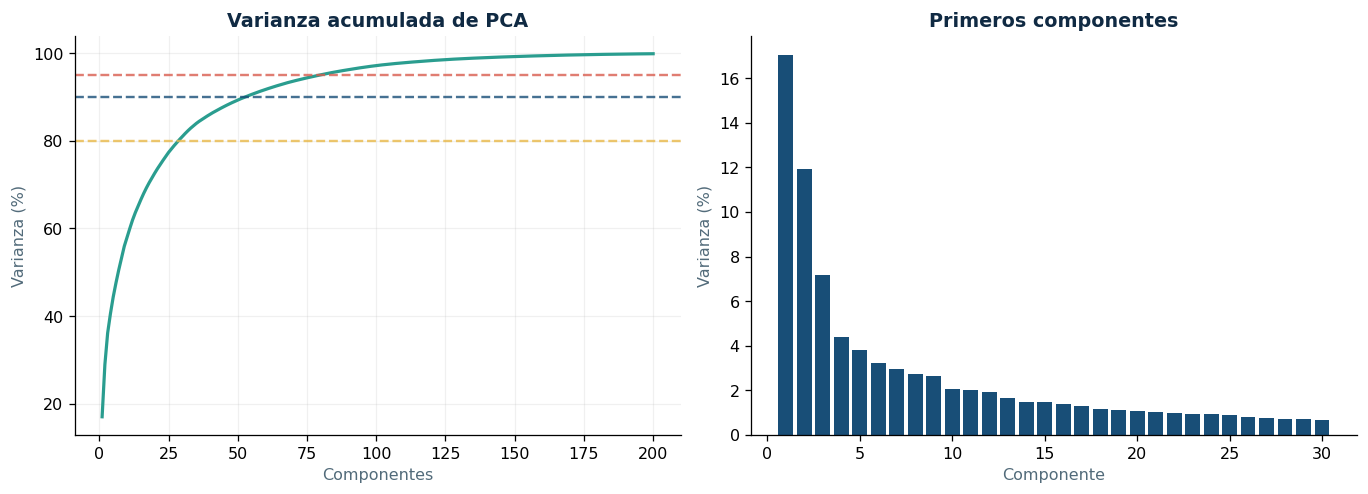

21346

In [10]:
v_cols=[c for c in sample.columns if re.fullmatch(r"V\d+",c)
        and sample[c].isna().mean()<.80 and sample[c].nunique(dropna=True)>1]
pca_source=sample[v_cols].sample(n=min(PCA_SAMPLE,len(sample)),random_state=SEED)
X_v=SimpleImputer(strategy="median").fit_transform(pca_source).astype("float32")
X_v=StandardScaler().fit_transform(X_v).astype("float32")
n_components=min(200,X_v.shape[1]-1,X_v.shape[0]-1)
pca=PCA(n_components=n_components,svd_solver="randomized",random_state=SEED).fit(X_v)
cumulative=np.cumsum(pca.explained_variance_ratio_)
def components_for(level):
    where=np.flatnonzero(cumulative>=level)
    return int(where[0]+1) if len(where) else f">{n_components}"
pca_summary=pd.DataFrame({"Varianza acumulada":["80%","90%","95%"],
    "Componentes requeridos":[components_for(.80),components_for(.90),components_for(.95)]})
display(pca_summary)
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
axes[0].plot(np.arange(1,len(cumulative)+1),cumulative*100,color=COLORS["teal"],lw=2)
for level,color in [(80,COLORS["gold"]),(90,COLORS["blue"]),(95,COLORS["red"])]:
    axes[0].axhline(level,color=color,ls="--",alpha=.8)
axes[0].set(title="Varianza acumulada de PCA",xlabel="Componentes",ylabel="Varianza (%)"); axes[0].grid(True)
axes[1].bar(np.arange(1,min(31,len(pca.explained_variance_ratio_)+1)),
            pca.explained_variance_ratio_[:30]*100,color=COLORS["blue"])
axes[1].set(title="Primeros componentes",xlabel="Componente",ylabel="Varianza (%)")
plt.tight_layout(); plt.show()
pca90=components_for(.90)
message=(f"Las {len(v_cols)} variables V alcanzan 90% de varianza con {pca90} componentes."
         if isinstance(pca90,int) else
         f"Ni {n_components} componentes alcanzan 90% para {len(v_cols)} variables V.")
display(HTML(f'<div class="callout"><b>Resultado.</b> {message} La siguiente fase debe '
             'comparar V seleccionadas, PCA y V completas con idéntica validación temporal.</div>'))
del X_v,pca_source; gc.collect()

<div class="section"><h2>9 · Deriva entre períodos</h2><p>Una variable asociada puede ser peligrosa si cambia en el futuro.</p></div>

PSI se usa como indicador descriptivo, no como prueba definitiva:

$$PSI=\sum_b(p_b-q_b)\log\left(\frac{p_b}{q_b}\right).$$

,variable,familia,psi_validacion,psi_benchmark,delta_missing_benchmark
48,V79,V (Vesta),0.0049,0.0213,-5.81%
49,V86,V (Vesta),0.0045,0.0202,-5.81%
50,V87,V (Vesta),0.0044,0.0199,-5.81%
9,V157,V (Vesta),0.0046,0.0161,+4.06%
21,V218,V (Vesta),0.0031,0.0157,+5.99%
27,V231,V (Vesta),0.0022,0.0155,+5.99%
29,V233,V (Vesta),0.0020,0.0142,+5.99%
5,V148,V (Vesta),0.0020,0.0137,+4.06%
28,V232,V (Vesta),0.0020,0.0136,+5.99%
20,V217,V (Vesta),0.0035,0.0132,+5.99%


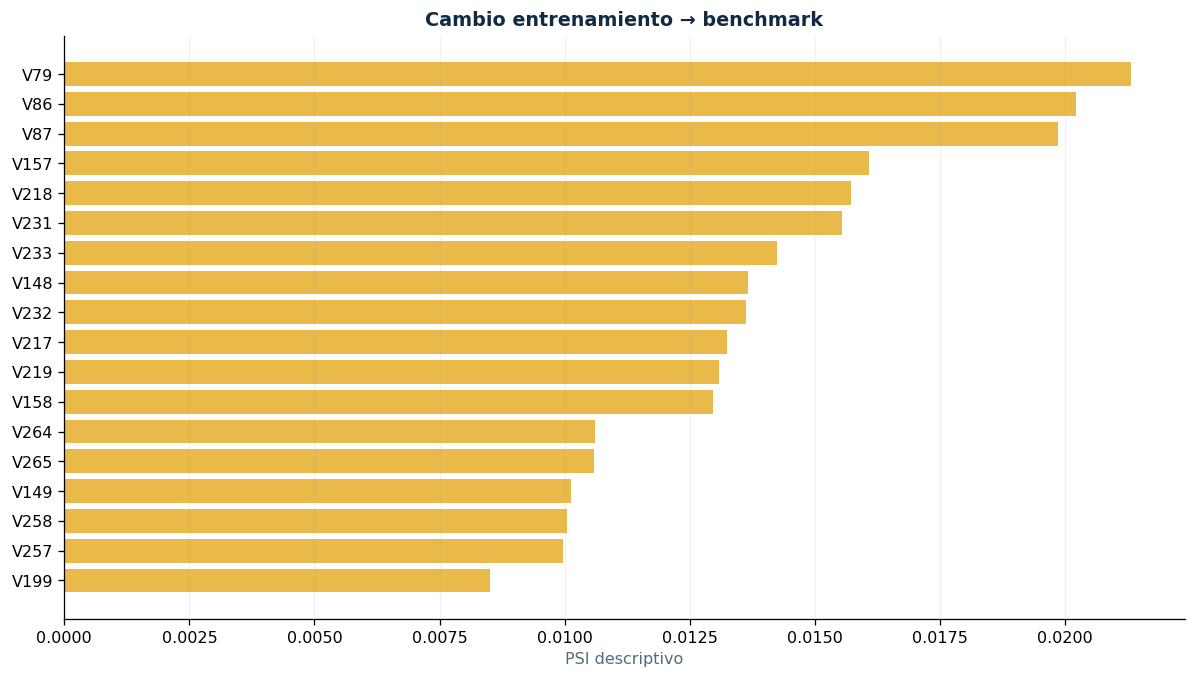

In [11]:
def psi_numeric(train_s,compare_s,bins=10):
    train_s=pd.to_numeric(train_s,errors="coerce"); compare_s=pd.to_numeric(compare_s,errors="coerce")
    clean=train_s.dropna()
    if clean.nunique()<2: return 0.0
    edges=np.unique(clean.quantile(np.linspace(0,1,bins+1)).to_numpy())
    if len(edges)<3: return 0.0
    edges[0],edges[-1]=-np.inf,np.inf
    p=pd.cut(train_s,edges,include_lowest=True).value_counts(normalize=True,sort=False)
    q=pd.cut(compare_s,edges,include_lowest=True).value_counts(normalize=True,sort=False)
    p=np.r_[p.to_numpy(),train_s.isna().mean()]+1e-6
    q=np.r_[q.to_numpy(),compare_s.isna().mean()]+1e-6
    p,q=p/p.sum(),q/q.sum()
    return float(np.sum((p-q)*np.log(p/q)))

drift_candidates=list(association.nlargest(35,"mutual_info").index.union(
                      association.nlargest(35,"abs_pearson").index))
train_s=sample[sample.periodo=="Entrenamiento"]; val_s=sample[sample.periodo=="Validación"]
test_s=sample[sample.periodo=="Benchmark"]; drift_rows=[]
for col in drift_candidates:
    if col not in sample or not pd.api.types.is_numeric_dtype(sample[col]): continue
    drift_rows.append({"variable":col,"familia":family(col),
        "psi_validacion":psi_numeric(train_s[col],val_s[col]),
        "psi_benchmark":psi_numeric(train_s[col],test_s[col]),
        "delta_missing_benchmark":test_s[col].isna().mean()-train_s[col].isna().mean()})
drift=pd.DataFrame(drift_rows).sort_values("psi_benchmark",ascending=False)
display(drift.head(25).style.format({"psi_validacion":"{:.4f}","psi_benchmark":"{:.4f}",
                                     "delta_missing_benchmark":"{:+.2%}"}))
plot_drift=drift.head(18).sort_values("psi_benchmark")
fig,ax=plt.subplots(figsize=(10.5,6))
ax.barh(plot_drift.variable,plot_drift.psi_benchmark,color=COLORS["gold"])
ax.set(title="Cambio entrenamiento → benchmark",xlabel="PSI descriptivo"); ax.grid(axis="x")
plt.tight_layout(); plt.show()
display(HTML(f'<div class="callout warn"><b>Riesgo temporal.</b> Las variables con mayor cambio '
             f'son <b>{", ".join(drift.head(5).variable.tolist())}</b>. Asociación alta sin '
             'estabilidad exige ablation y monitoreo.</div>'))

<div class="section"><h2>10 · Calidad de la entidad secuencial</h2><p>Se comparan proxies sin afirmar que representen a una persona real.</p></div>

Para una entidad con $n$ eventos, las filas con al menos $k$ antecedentes son $\max(n-k,0)$.

,columnas,entidades,mediana_eventos,p95_eventos,entidades_singleton,filas_con_3_antecedentes,filas_con_8_antecedentes,filas_con_16_antecedentes
clave,,,,,,,,
Tarjeta + dirección,card1 + addr1,"39,974",2.0,45.0,39.4%,86.0%,76.0%,66.8%
Tarjeta ampliada + dirección (V6),card1 + card2 + card3 + card5 + addr1,"42,946",2.0,42.0,40.3%,85.1%,74.7%,65.3%
V6 + correo,card1 + card2 + card3 + card5 + addr1 + P_emaildomain,"94,801",2.0,20.0,49.1%,70.1%,54.5%,42.9%
Tarjeta + dirección + producto + correo,card1 + addr1 + ProductCD + P_emaildomain,"106,319",1.0,17.0,52.3%,67.7%,52.0%,40.7%


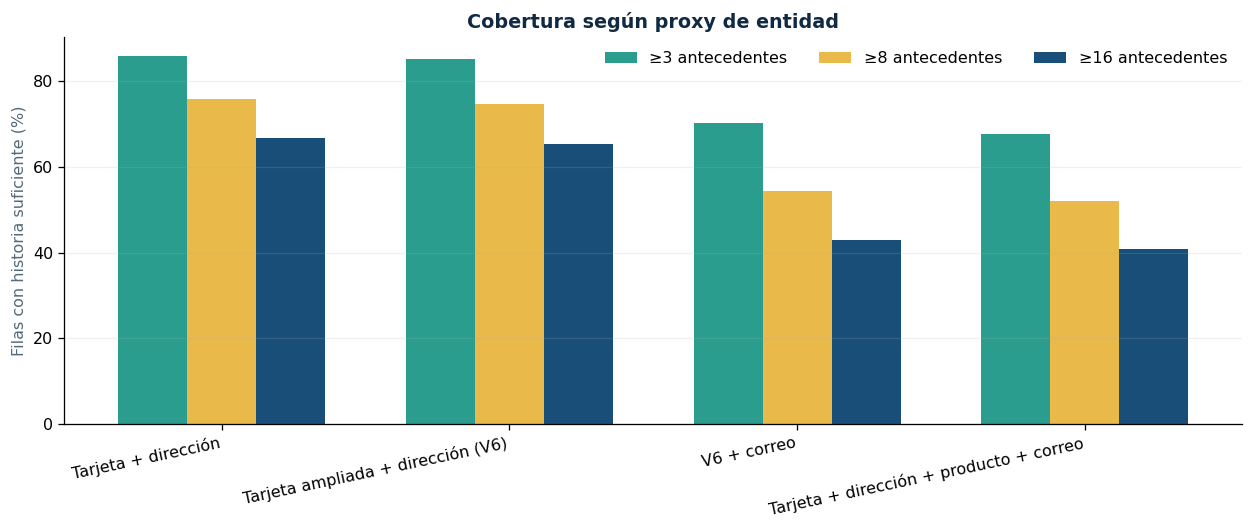

In [12]:
key_definitions={
    "Tarjeta + dirección":["card1","addr1"],
    "Tarjeta ampliada + dirección (V6)":["card1","card2","card3","card5","addr1"],
    "V6 + correo":["card1","card2","card3","card5","addr1","P_emaildomain"],
    "Tarjeta + dirección + producto + correo":["card1","addr1","ProductCD","P_emaildomain"]}
entity_rows=[]
for name,cols in key_definitions.items():
    sizes=core.groupby(cols,dropna=False,observed=True).size()
    entity_rows.append({"clave":name,"columnas":" + ".join(cols),"entidades":len(sizes),
        "mediana_eventos":sizes.median(),"p95_eventos":sizes.quantile(.95),
        "entidades_singleton":(sizes==1).mean(),
        "filas_con_3_antecedentes":np.maximum(sizes.to_numpy()-3,0).sum()/len(core),
        "filas_con_8_antecedentes":np.maximum(sizes.to_numpy()-8,0).sum()/len(core),
        "filas_con_16_antecedentes":np.maximum(sizes.to_numpy()-16,0).sum()/len(core)})
entity_diag=pd.DataFrame(entity_rows).set_index("clave")
display(entity_diag.style.format({"entidades":"{:,.0f}","mediana_eventos":"{:.1f}","p95_eventos":"{:.1f}",
    "entidades_singleton":"{:.1%}","filas_con_3_antecedentes":"{:.1%}",
    "filas_con_8_antecedentes":"{:.1%}","filas_con_16_antecedentes":"{:.1%}"}))
fig,ax=plt.subplots(figsize=(11,4.7)); x=np.arange(len(entity_diag)); width=.24
coverage=["filas_con_3_antecedentes","filas_con_8_antecedentes","filas_con_16_antecedentes"]
for j,col in enumerate(coverage):
    ax.bar(x+(j-1)*width,entity_diag[col]*100,width=width,
           label=col.replace("filas_con_","≥").replace("_antecedentes"," antecedentes"),
           color=[COLORS["teal"],COLORS["gold"],COLORS["blue"]][j])
ax.set_xticks(x,entity_diag.index,rotation=12,ha="right")
ax.set(title="Cobertura según proxy de entidad",ylabel="Filas con historia suficiente (%)")
ax.legend(frameon=False,ncol=3); ax.grid(axis="y"); plt.tight_layout(); plt.show()
current=entity_diag.loc["Tarjeta ampliada + dirección (V6)"]
display(HTML(f'<div class="callout stop"><b>Limitación estructural de B.</b> La clave V6 ofrece '
             f'al menos 8 antecedentes al {current["filas_con_8_antecedentes"]:.1%} de filas y 16 al '
             f'{current["filas_con_16_antecedentes"]:.1%}. Cobertura no equivale a identidad correcta; '
             'una GRU mayor no corrige historias mezcladas.</div>'))

<div class="section"><h2>11 · Diagnóstico integrado y siguiente iteración</h2><p>El EDA termina con decisiones verificables, no con una lista genérica de modelos.</p></div>

In [13]:
top_features=association.head(12).index.tolist()
joined=association.join(drift.set_index("variable")[["psi_benchmark"]],how="left")
top_stable=(joined[joined.psi_benchmark.fillna(np.inf)<.25]
            .sort_values(["mutual_info","abs_pearson"],ascending=False).head(12).index.tolist())
conclusions=f'''
<div class="verdict">
  <div><b>1 · No es solo capacidad</b><br>Hay asociaciones no lineales y patrones de ausencia. Variables destacadas: {", ".join(top_features[:6])}.</div>
  <div><b>2 · Hay redundancia</b><br>Se encontraron {len(strong_pairs)} pares con |ρ| ≥ 0.95; la selección por grupos puede beneficiar modelos lineales y neuronales.</div>
  <div><b>3 · PCA es una ablation</b><br>El 90% de varianza de {len(v_cols)} variables V requiere {components_for(.90)} componentes; esto no demuestra mejor AP.</div>
  <div><b>4 · La identidad limita la GRU</b><br>La cobertura histórica no demuestra que los eventos pertenezcan a la misma persona.</div>
  <div><b>5 · Existe deriva</b><br>Mayor cambio relativo: {", ".join(drift.head(5).variable.tolist())}. Asociación sin estabilidad puede degradar el futuro.</div>
  <div><b>6 · Punto de partida</b><br>Priorizar variables asociadas y estables: {", ".join(top_stable[:6])}; conservar faltantes útiles y excluir IDs como magnitudes.</div>
</div>'''
display(HTML(conclusions))
experiments=pd.DataFrame([
    ("E0","Regresión logística","Variables filtradas + codificación + faltantes","Control lineal y calibración"),
    ("E1","LightGBM","Variables ampliadas + agregados causales","Baseline principal"),
    ("E2","LightGBM reducido","Selección por estabilidad, asociación y redundancia","Medir si menos ruido generaliza mejor"),
    ("E3","Logística/MLP + PCA","PCA de V ajustado solo en train","Ablation de compresión"),
    ("E4","GRU revisada","Solo tras mejorar identidad y demostrar valor del orden","Validar señal secuencial")
],columns=["Experimento","Modelo","Representación","Pregunta"])
display(experiments)
display(HTML('<div class="callout"><b>Decisión previa al modelado.</b> Congelar ventanas '
    'walk-forward; ajustar selección, imputación, codificación y PCA dentro de train; comparar '
    'AP, recall, precisión, costo, calibración y estabilidad. No perseguir un 0.90 universal: '
    'la mejora debe superar A sin comprar falsas alarmas desproporcionadas.</div>'))

,Experimento,Modelo,Representación,Pregunta
0,E0,Regresión logística,Variables filtradas + codificación + faltantes,Control lineal y calibración
1,E1,LightGBM,Variables ampliadas + agregados causales,Baseline principal
2,E2,LightGBM reducido,"Selección por estabilidad, asociación y redund...",Medir si menos ruido generaliza mejor
3,E3,Logística/MLP + PCA,PCA de V ajustado solo en train,Ablation de compresión
4,E4,GRU revisada,Solo tras mejorar identidad y demostrar valor ...,Validar señal secuencial


<div class="section"><h2>12 · Límites y trazabilidad</h2><p>Qué demuestra este cuaderno y qué queda pendiente.</p></div>

| Aspecto | Alcance de este EDA | Control obligatorio |
|---|---|---|
| Faltantes y cardinalidad | Estadísticas globales exactas | Aprender reglas de eliminación solo con train |
| Asociación y correlación | Muestra temporal reproducible | Repetir selección dentro de cada ventana |
| PCA | Diagnóstico de varianza de la familia V | Ajustar imputador, escalador y PCA solo en train |
| Deriva | Comparación descriptiva entre períodos | Confirmar en una cohorte futura |
| Identidad | Cobertura de cuatro proxies | Validar colisiones con identidad real |
| Causalidad | No se construyen agregados futuros | Auditar cada nueva historia con $t_j<t$ |

<div class="callout stop"><b>Límite principal:</b> el EDA identifica candidatos y riesgos, pero no demuestra causalidad ni que PCA mejore AP. Cada propuesta requiere una ablation temporal congelada.</div>

Quedan disponibles en memoria las tablas <code>association</code>, <code>missing_signal</code>, <code>strong_pairs</code>, <code>drift</code>, <code>entity_diag</code> y <code>pca_summary</code> para especificar la siguiente fase.